# Plotting a graph over time of the affilitions

In [35]:
import pandas as pd
import numpy as np
JPE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Melted_Weights_applied.xlsx') 
print(JPE.shape)
JPE = JPE[['Article_ID','Weight','Affiliation','year']]
JPE = JPE.reset_index(drop=True)

QJE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/QJE_Melted_Weights_applied.xlsx') 
print(QJE.shape)
QJE = QJE[['Article_ID','Weight','Affiliation','year']]
QJE = QJE.reset_index(drop=True)

RES = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/RES_Melted_Weights_applied.xlsx') 
print(RES.shape)
RES = RES[['Article_ID','Weight','Affiliation','year']]
RES = RES.reset_index(drop=True)

AER = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/AER_Melted_Weights_applied.xlsx') 
print(AER.shape)
AER = AER[['Article_ID','Weight','Affiliation','year']]
AER = AER.reset_index(drop=True)

ECTA = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/ECTA_Melted_Weights_applied.xlsx') 
print(ECTA.shape)
ECTA = ECTA[['Article_ID','Weight','Affiliation','year']]
ECTA = ECTA.reset_index(drop=True)


(6304, 7)
(5172, 7)
(4309, 7)
(15282, 7)
(6726, 7)


In [36]:
melted_master_condenced = pd.concat([JPE, QJE, RES, AER, ECTA])
melted_master_condenced = melted_master_condenced.replace('University Of Wisconsin-Madison', 'University Of Wisconsin')

In [37]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight              Affiliation  year       decade
0     1825913     1.0     Washington Dc (City)  1940  [1940,1949]
1     1825908     1.0    University Of Chicago  1940  [1940,1949]
2     1824384     1.0      Columbia University  1940  [1940,1949]
3     1824382     1.0       Cornell University  1940  [1940,1949]
4     1824381     1.0  University Of Edinburgh  1940  [1940,1949]
      Article_ID  Weight                Affiliation  year       decade
6721    25621405     1.0    University Of Rochester  2010  [2000,2010]
6722    25621404     0.5                  Hec Paris  2010  [2000,2010]
6723    25621403     0.5    University Of Minnesota  2010  [2000,2010]
6724    25621401     0.5  University College London  2010  [2000,2010]
6725    40928462     0.5         Harvard University  2010  [2000,2010]


# Ranking the Universities based on their number of papers per published per decade

In [38]:
mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research', 'None'])
melted_master_condenced = melted_master_condenced[~mask_journal]

#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(50,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(50, 6)
University Of California, Berkeley
      Article_ID  Weight                         Affiliation       decade  \
949      1812743     1.0  University Of California, Berkeley  [1940,1949]   
709      1826697     1.0  University Of California, Berkeley  [1950,1959]   
683      2296468     1.0  University Of California, Berkeley  [1960,1969]   
1744     1882603     0.5  University Of California, Berkeley  [1970,1979]   
7785     1827943     1.0  University Of California, Berkeley  [1980,1989]   

      aff_cum_counts_yearly  
949               18.883333  
709               37.500000  
683               78.416667  
1744              74.000000  
7785              91.416667  
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/2280594778.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [39]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
#print(a['Affiliation'])

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
#print(b['Affiliation'])

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

z = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[25,2]]
z['aff_cum_sum_decade'] = z.groupby(['Affiliation','decade'])['Weight'].cumsum()
z = z.drop_duplicates(subset = ['decade'], keep = 'last')
print(z.shape)

a1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[26,2]]
a1['aff_cum_sum_decade'] = a1.groupby(['Affiliation','decade'])['Weight'].cumsum()
a1= a1.drop_duplicates(subset = ['decade'], keep = 'last')
print(a1.shape)
print(a1['Affiliation'])

b1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[27,2]]
b1['aff_cum_sum_decade'] = b1.groupby(['Affiliation','decade'])['Weight'].cumsum()
b1 = b1.drop_duplicates(subset = ['decade'], keep = 'last')
print(b1.shape)
print(b1['Affiliation'])

c1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[28,2]]
c1['aff_cum_sum_decade'] = c1.groupby(['Affiliation','decade'])['Weight'].cumsum()
c1 = c1.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d1= melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[29,2]]
d1['aff_cum_sum_decade'] = d1.groupby(['Affiliation','decade'])['Weight'].cumsum()
d1 = d1.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[30,2]]
e1['aff_cum_sum_decade'] = e1.groupby(['Affiliation','decade'])['Weight'].cumsum()
e1 = e1.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[31,2]]
f1['aff_cum_sum_decade'] = f1.groupby(['Affiliation','decade'])['Weight'].cumsum()
f1 = f1.drop_duplicates(subset = ['decade'], keep = 'last')

g1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[32,2]]
g1['aff_cum_sum_decade'] = g1.groupby(['Affiliation','decade'])['Weight'].cumsum()
g1 = g1.drop_duplicates(subset = ['decade'], keep = 'last')

h1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[33,2]]
h1['aff_cum_sum_decade'] = h1.groupby(['Affiliation','decade'])['Weight'].cumsum()
h1 = h1.drop_duplicates(subset = ['decade'], keep = 'last')

i1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[34,2]]
i1['aff_cum_sum_decade'] = i1.groupby(['Affiliation','decade'])['Weight'].cumsum()
i1= i1.drop_duplicates(subset = ['decade'], keep = 'last')

j1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[35,2]]
j1['aff_cum_sum_decade'] = j1.groupby(['Affiliation','decade'])['Weight'].cumsum()
j1 = j1.drop_duplicates(subset = ['decade'], keep = 'last')

k1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[36,2]]
k1['aff_cum_sum_decade'] = k1.groupby(['Affiliation','decade'])['Weight'].cumsum()
k1 = k1.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[37,2]]
l1['aff_cum_sum_decade'] = l1.groupby(['Affiliation','decade'])['Weight'].cumsum()
l1 = l1.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[38,2]]
m1['aff_cum_sum_decade'] = m1.groupby(['Affiliation','decade'])['Weight'].cumsum()
m1 = m1.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[39,2]]
n1['aff_cum_sum_decade'] = n1.groupby(['Affiliation','decade'])['Weight'].cumsum()
n1 = n1.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[40,2]]
o1['aff_cum_sum_decade'] = o1.groupby(['Affiliation','decade'])['Weight'].cumsum()
o1 = o1.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p1= melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[41,2]]
p1['aff_cum_sum_decade'] = p1.groupby(['Affiliation','decade'])['Weight'].cumsum()
p1 = p1.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[42,2]]
q1['aff_cum_sum_decade'] = q1.groupby(['Affiliation','decade'])['Weight'].cumsum()
q1 = q1.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[43,2]]
r1['aff_cum_sum_decade'] = r1.groupby(['Affiliation','decade'])['Weight'].cumsum()
r1 = r1.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[44,2]]
s1['aff_cum_sum_decade'] = s1.groupby(['Affiliation','decade'])['Weight'].cumsum()
s1 = s1.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[45,2]]
t1['aff_cum_sum_decade'] = t1.groupby(['Affiliation','decade'])['Weight'].cumsum()
t1 = t1.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[46,2]]
u1['aff_cum_sum_decade'] = u1.groupby(['Affiliation','decade'])['Weight'].cumsum()
u1 = u1.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[47,2]]
v1['aff_cum_sum_decade'] = v1.groupby(['Affiliation','decade'])['Weight'].cumsum()
v1 = v1.drop_duplicates(subset = ['decade'], keep = 'last')

w1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[48,2]]
w1['aff_cum_sum_decade'] = w1.groupby(['Affiliation','decade'])['Weight'].cumsum()
w1 = w1.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x1 = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[49,2]]
x1['aff_cum_sum_decade'] = x1.groupby(['Affiliation','decade'])['Weight'].cumsum()
x1= x1.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:12: SettingWithCopyWa

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:82: SettingWithCopy

(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
845      University Of Washington
1866     University Of Washington
719      University Of Washington
4964     University Of Washington
2581     University Of Washington
4988     University Of Washington
14833    University Of Washington
Name: Affiliation, dtype: object


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b1['aff_cum_sum_decade'] = b1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c1['aff_cum_sum_decade'] = c1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:149: SettingW

(7, 5)
983      University Of Toronto
702      University Of Toronto
1434     University Of Toronto
2678     University Of Toronto
2577     University Of Toronto
10758    University Of Toronto
15242    University Of Toronto
Name: Affiliation, dtype: object
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:175: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j1['aff_cum_sum_decade'] = j1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:179: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  k1['aff_cum_sum_decade'] = k1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:184: SettingW

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(6, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:219: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s1['aff_cum_sum_decade'] = s1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:224: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t1['aff_cum_sum_decade'] = t1.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6221/137813301.py:229: SettingW

In [40]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,a1,b1,c1,d1,e1,f1,g1,h1,i1,j1,k1,l1,m1,n1,o1,p1,q1,r1,s1,t1,u1,v1,w1,x1], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(328, 5)
(328, 6)
       Article_ID    Weight                            Affiliation  \
6685     40664488  0.500000        University Of California, Davis   
15060    27804965  0.250000  University Of California, Los Angeles   
14932    41038753  0.500000    University Of California, San Diego   
15000    27871262  0.500000                University Of Cambridge   
15020    41038752  0.333333                  University Of Chicago   
3717      3700649  1.000000                 University Of Illinois   
15018    27805061  0.500000                 University Of Maryland   
14983    27804923  1.000000                 University Of Michigan   
15055    27871263  0.250000                University Of Minnesota   
15015    27871267  0.333333                   University Of Oxford   
15079    27871241  0.333333             University Of Pennsylvania   
15102    27805021  0.333333                University Of Rochester   
15242    27805013  0.500000                  University Of Toronto   
15

In [41]:
ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [42]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})

In [43]:

ranked = ranked.fillna(0)

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)

invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].fillna(0).astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
invert_pivot
invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/All weight 50 pivot.xlsx') 
invert_pivot

Year Bucket,"[1940,1949]","[1950,1959]","[1960,1969]","[1970,1979]","[1980,1989]","[1990,1999]","[2000,2010]",Total papers,Average Paper per decade
Affiliation,,,,,,,,,
Harvard University,125,97,116,201,168,193,222,1124,281
University Of Chicago,104,87,136,148,125,146,174,922,230
Massachusetts Institute Of Technology,36,68,108,110,159,151,145,778,194
Stanford University,22,62,73,111,132,111,148,661,165
Princeton University,38,38,65,84,141,100,124,594,148
Yale University,40,59,99,111,109,86,86,593,148
"University Of California, Berkeley",18,37,78,74,91,78,133,512,128
Northwestern University,12,37,42,79,96,111,119,499,124
University Of Pennsylvania,20,25,66,75,113,83,88,472,118


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

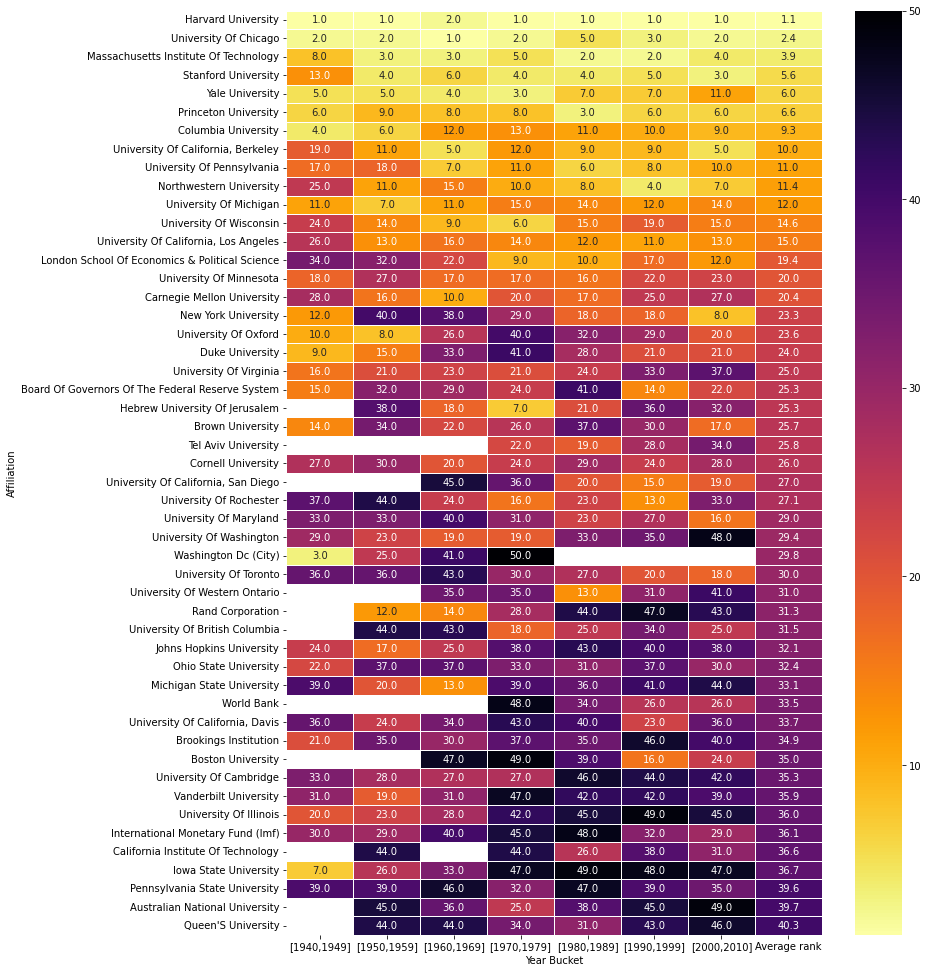

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
ranked['Rank'] = ranked['Rank'].astype(int)
#print(ranked.head())
invert_pivot2 = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot2['Average rank'] = invert_pivot2.mean(axis=1)

invert_pivot2 = invert_pivot2.sort_values(by='Average rank', ascending=True)
f, ax = plt.subplots(figsize=(12, 17))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot2, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

In [45]:
invert_pivot2['Lowest_rank'] = invert_pivot2.min(axis=1)
invert_pivot2['Higest rank'] = invert_pivot2.max(axis=1)
invert_pivot2['Change in rank'] = invert_pivot2['Higest rank'] - invert_pivot2['Lowest_rank']
invert_pivot2 = invert_pivot2.sort_values(by='Change in rank', ascending=True)

invert = invert_pivot2.reset_index()
invert.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.5. Comparing weighted to count/All weighted.xlsx') 

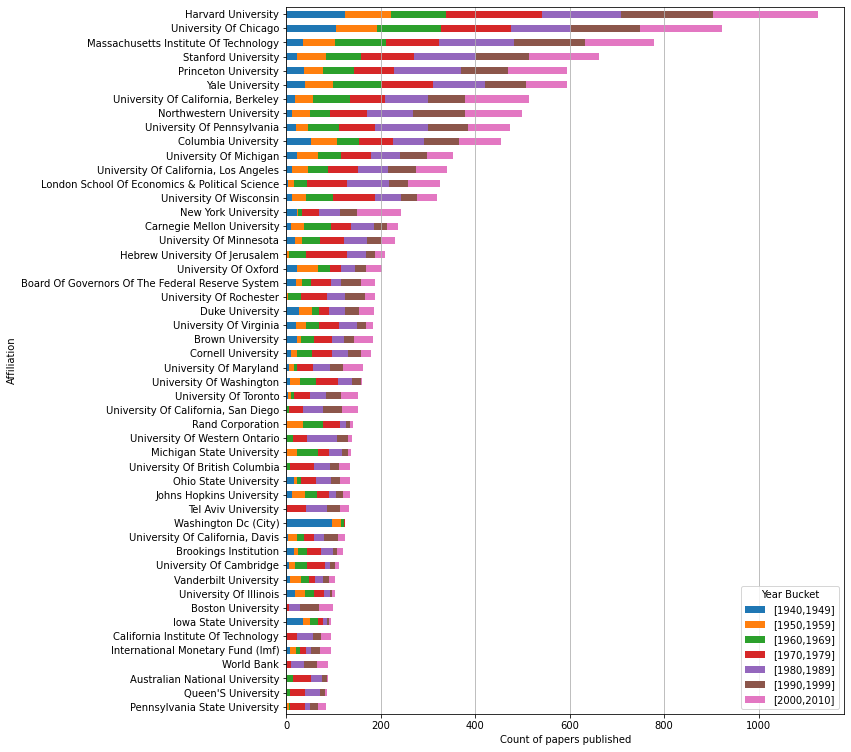

In [46]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
#print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)
ax = p.plot.barh(stacked=True, figsize=(10, 13))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Count of papers published')
plt.grid(axis = 'x')
plt.get_cmap('inferno_r')
plt.show()
